In [1]:
# test out aligning the two PET scans and then subtracting 

from nilearn.plotting import plot_stat_map
import os
import numpy as np
import nibabel as nb
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = os.path.dirname(os.getcwd())
SUVRs = BASE_PATH + '/SUVRs/'
output_dir = BASE_PATH + '/qc/'

fsl_dir=os.environ['FSL_DIR']
mni152_brain=fsl_dir + '/data/standard/MNI152_T1_2mm_brain.nii.gz'

In [3]:
files = []
for f in os.listdir(SUVRs): 
    if 'mni152.2mm.sm00.nii.gz' in f:
        files.append(f)
files.sort()

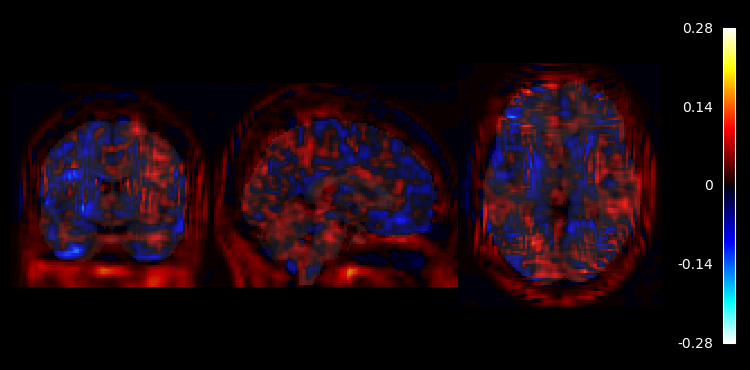

In [69]:
mni152_mask=nb.load(fsl_dir + '/data/standard/MNI152_T1_2mm_brain_mask.nii.gz').get_fdata()
affine = nb.load(SUVRs + files[0]).affine

active_file = SUVRs + files[0]
active= nb.load(active_file).get_fdata()

sham_file = SUVRs + files[1]
sham = nb.load(sham_file).get_fdata()


subs = active - sham

img = nb.Nifti1Image(subs, affine)

display = plot_stat_map(    
        img,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.8,
        cut_coords=(0,0,0),
        annotate=False
    );

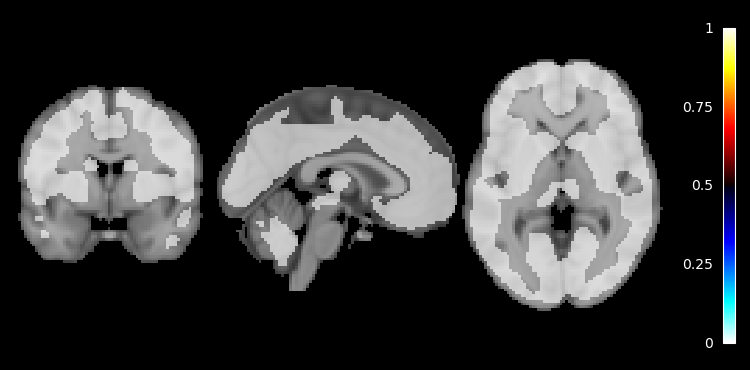

In [38]:
active= (active>0.1) * np.ones(active.shape)
act_img = nb.Nifti1Image(active, affine)



display = plot_stat_map(    
        act_img,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.6,
        cut_coords=(0,0,0),
        annotate=False
    );

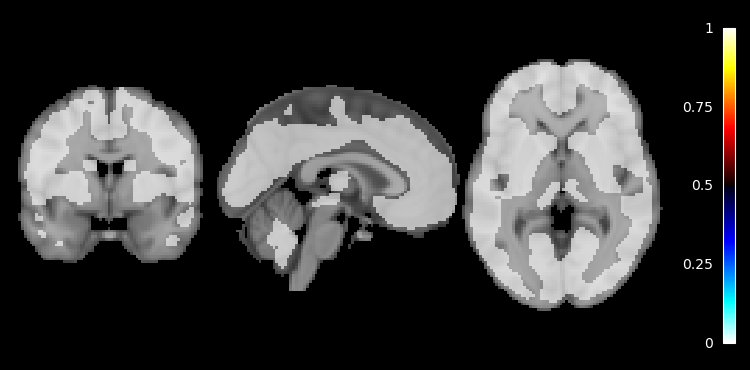

In [39]:
sham= (sham>.1) * np.ones(sham.shape)
sham_img = nb.Nifti1Image(sham, affine)


display = plot_stat_map(    
        sham_img,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.6,
        cut_coords=(0,0,0),
        annotate=False
    );

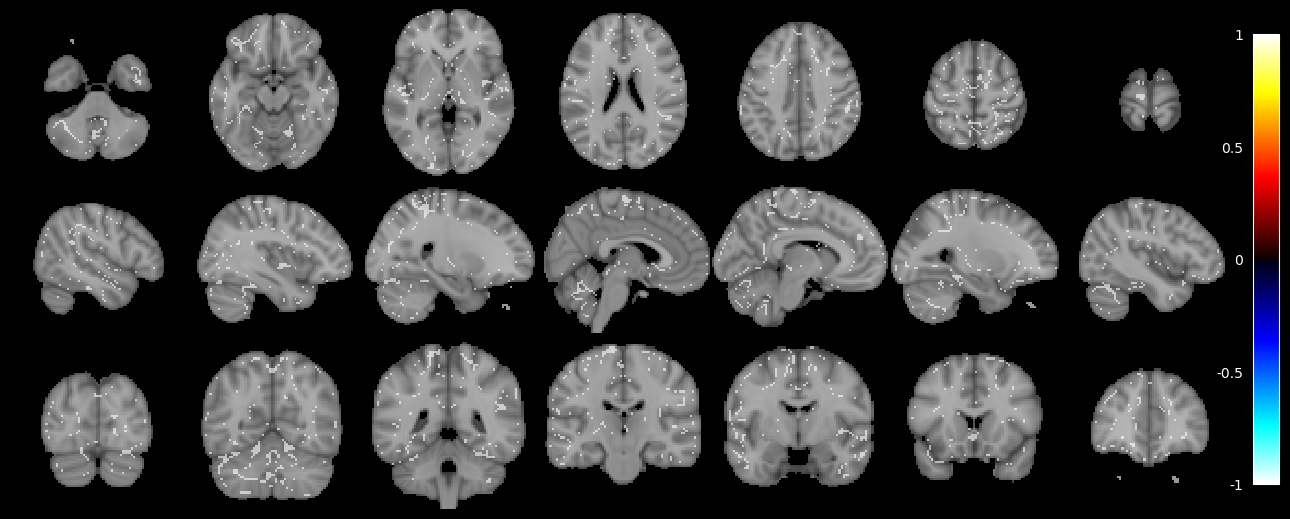

In [43]:
subs = active - sham 
img = nb.Nifti1Image(subs, affine)

display = plot_stat_map(    
        img,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.6,
        display_mode='mosaic',
        annotate=False
    );

In [ ]:
from nipype.interfaces import fsl

flt = fsl.FLIRT()
flt.inputs.in_file = active_file
flt.inputs.reference = sham_file
flt.inputs.output_type = "NIFTI_GZ"
flt.inputs.out_file = '/home/lauri/Documents/TMS-FDG/tbsfdg/SUVRs/test.nii.gz'
flt.inputs.out_matrix_file = '/home/lauri/Documents/TMS-FDG/tbsfdg/SUVRs/test.mat'
flt.cmdline 
res = flt.run() 

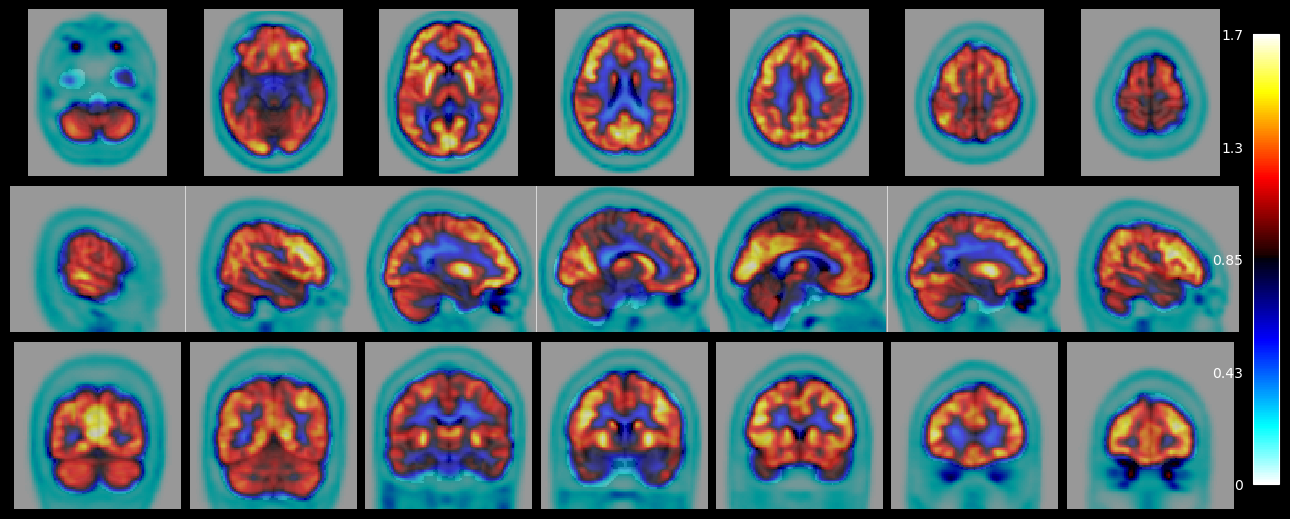

In [66]:
realigned = nb.load(res.outputs.out_file)


display = plot_stat_map(    
        realigned,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.6,
        display_mode='mosaic',
        annotate=False
    );

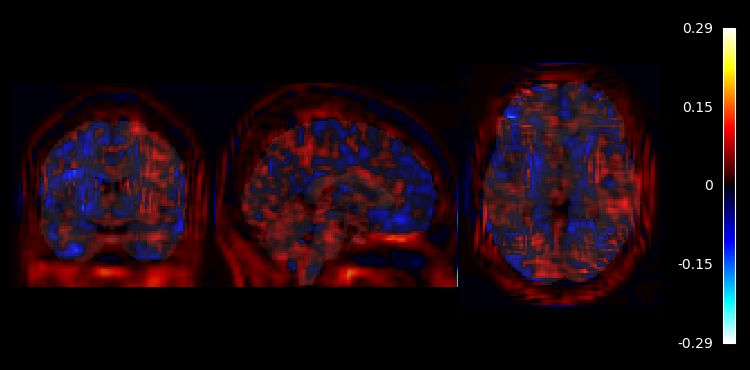

In [68]:
realigned_act = nb.load(res.outputs.out_file).get_fdata()

sham_file = SUVRs + files[1]
sham = nb.load(sham_file).get_fdata()


subs = realigned_act - sham

img = nb.Nifti1Image(subs, affine)

display = plot_stat_map(    
        img,
        bg_img=mni152_brain,
        threshold=0,
        draw_cross=False,
        alpha = 0.8,
        cut_coords=(0,0,0),
        annotate=False
    );